In [1]:
"""
Better organized science plots. Use cmz_scratch.ipynb for scratch work
"""
import sys
import os.path

path = "~/apps/kratos/visual"
full_path = os.path.expanduser(path)

%env KRATOS_VISUAL_DIR=$full_path
sys.path.append( "../visual" )
from proxy import *
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
%autoreload 2
#%aimport binary_io
#%aimport hydro_data
#%aimport slice_plot
#%aimport cmz_init
%aimport proxy
%matplotlib inline
from matplotlib import rc

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})

plt.rcParams[ "text.usetex" ] = True

env: KRATOS_VISUAL_DIR=/home/cmz_colab/apps/kratos/visual


soxs : [WARNING  ] 2026-06-30 03:50:05,057 Setting 'soxs_data_dir' to /home/cmz_colab/.cache/soxs for this session. Please update your configuration if you want it somewhere else.


file: ../../cmz/cmz_test/outputs/cmz_fid4_b60_00050.bin; time = 250
x0 not found


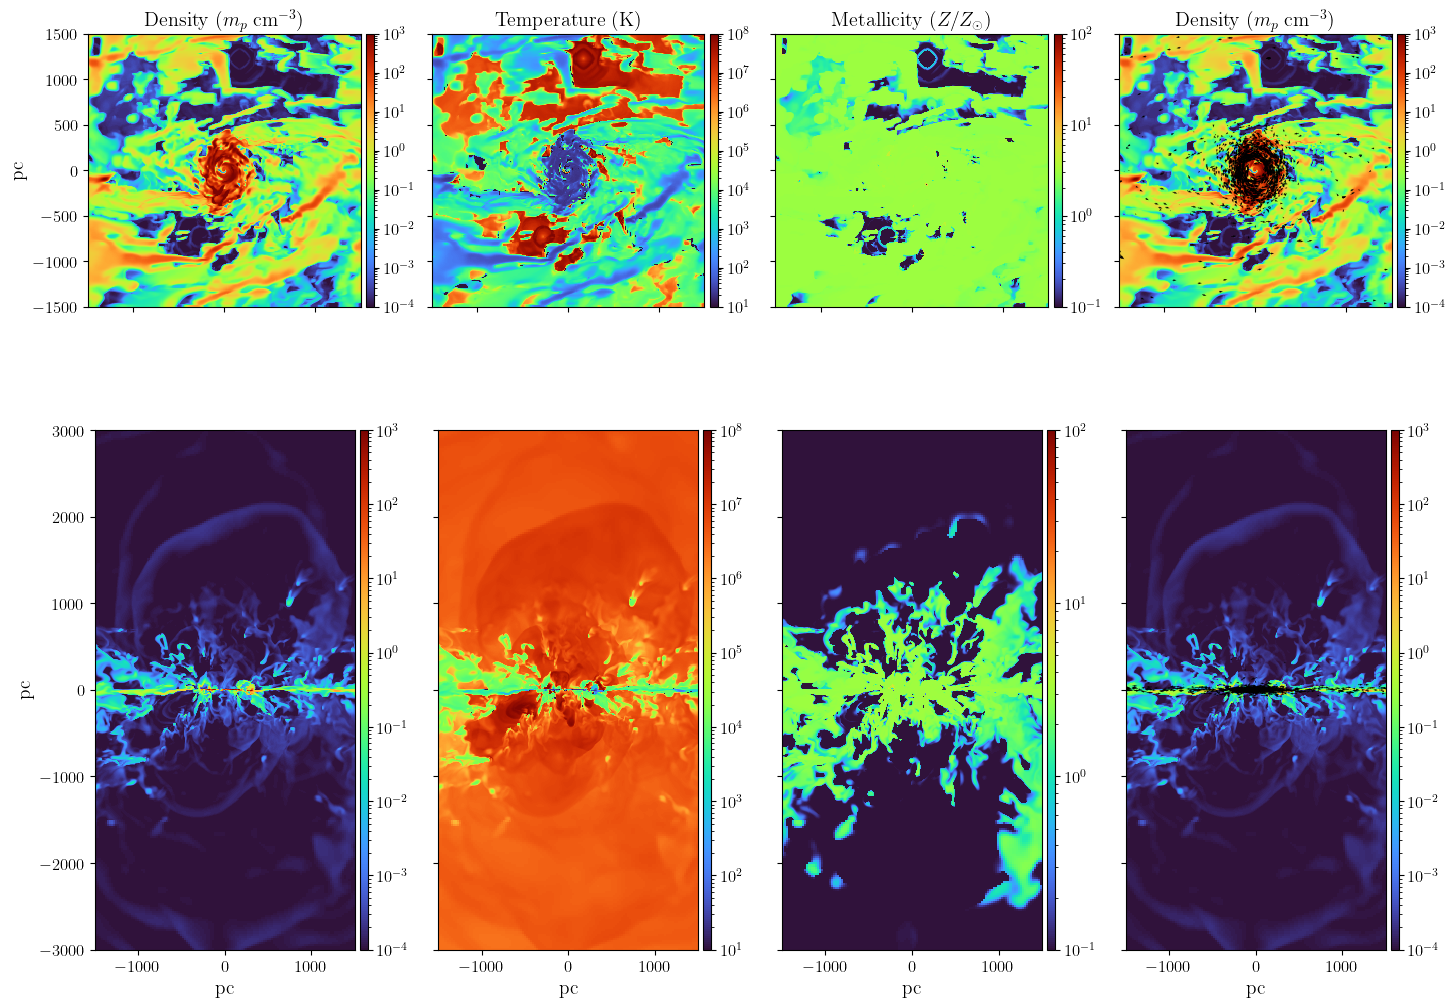

In [19]:
#d  = get_last_dd( f'../cmz/cmz_test/outputs/cmz_fb3_b3e3_{fstring( 30 )}.bin', -1, enroll_prim=True, data_type = galaxy_data );
d  = get_last_dd( f'../../cmz/cmz_test/outputs/cmz_fid4_b60_{fstring( 50 )}.bin', -1, enroll_prim=True, data_type = galaxy_data );
fig2 = f_plot_grid( d,  figsize=( 17, 13.5 )# , 
                    #,xlims = [ ( -12000, 12000 ), ( -12000, 12000 ) ] 
                    #,ylims = [ ( -12000, 12000 ), ( -12000, 12000 ) ]#,
                    #log   = [ True, True, True, False ],
                    #locs  = [ [ 1e-2, 1e-2, 1e-2, 2 ], [ 1e-2, 1e-2, 1e-2, 1e-2, 1e-2 ] ],
                    #axes  = 2,
                    #z0s   = [ 1, 1, -1, 1 / ( 4 * np.pi * G_code ) ],
                    #z0s   = [ 1, 1, 1, 1, -1 ],
                    #flds  = [ 'rho', 'T_ent', 'met', 'rho' ],
                    #zlims = [ ( 1e-4, 1e4 ), ( 1e1, 1e8 ), ( 1e-1, 1e2 ), ( 1e-2, 1e3 ) ],
                    #part_plot_i = [] )#( 1e-4, 1 ) ] )
                    )

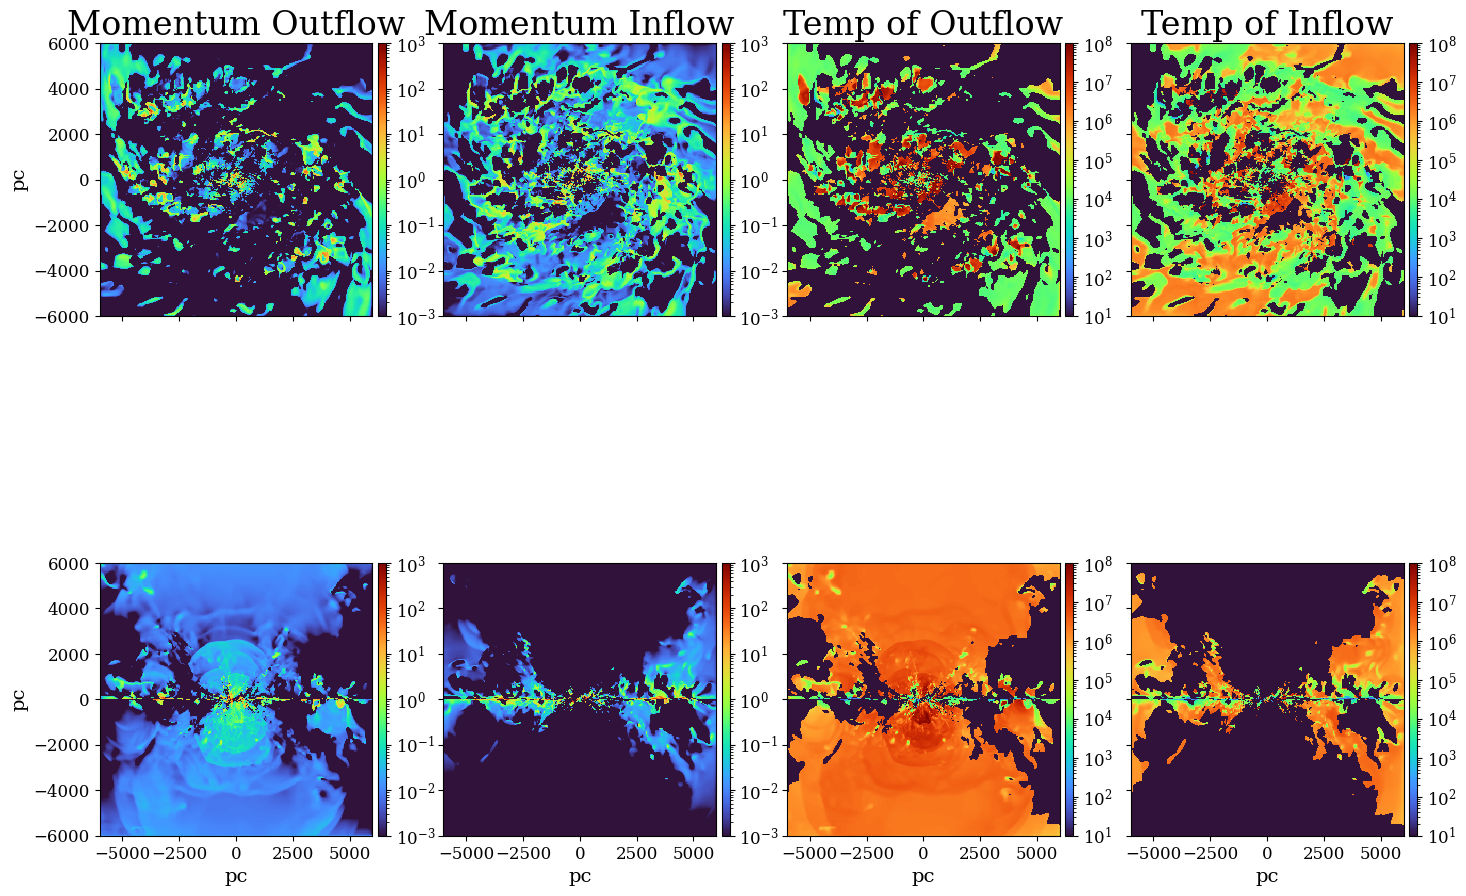

In [23]:
%reload_ext autoreload
#d  = get_last_dd( f'../cmz/cmz_test/outputs/cmz_fb4_nobondi_{fstring( 20 )}.bin', -1, enroll_prim=True, data_type = cmz_data );
#enroll_flux( d, 'mass', lambda bd : bd[ 'rho' ] * np.prod( bd[ 'dx' ], axis=0 ) )
#enroll_flux( d, 'met_fld' )
enroll_vel( d )
enroll_sgn( d, 'mom' )
enroll_sgn( d, "T_ent", "sgnvel" )
enroll_sgn( d, "met", "sgnvel" )

#R<500 z<140 definition of CMZ per 3-D CMZ battersby+2024

fig2 = f_plot_grid( d,  figsize=( 17, 13.5 ), 
                    xlims = [ ( -6000, 6000 ), ( -6000, 6000 ) ], 
                    ylims = [ ( -6000, 6000 ), ( -6000, 6000 ) ],
                    #log   = [ True, True, True, False ],
                    locs  = [ [ 140, 140, 140, 140 ],#, 140, 140 ], 
                              [ 1e-2, 1e-2, 1e-2, 1e-2 ] ],#, 1e-2, 1e-2 ] ],
                    #axes  = 2,
                    #z0s   = [ 1, 1, -1, 1 / ( 4 * np.pi * G_code ) ],
                    z0s   = [ 1, -1, 1, -1 ],#, 1, -1 ],
                    flds  = [ 'sgnmom[2]', 'sgnmom[2]', 'sgnT_ent[2]', 'sgnT_ent[2]' ],#, 'sgnflux_met_fld[2]', 'sgnflux_met_fld[2]' ],
                    names = [ 'Momentum Outflow', "Momentum Inflow", "Temp of Outflow", "Temp of Inflow" ],#,"Met Outflow", "Met Inflow" ],
                    zlims = [ ( 1e-3,1e3 ), ( 1e-3, 1e3 ), ( 1e1, 1e8 ), ( 1e1, 1e8 ) ],#, ( 1e-4,1e4 ), ( 1e-4, 1e4 ) ],
                    part_plot_i = [] )#( 1e-4, 1 ) ] )

/mnt/scratch/cmz/kratos_galaxy/notebooks/../visual/plot_gal.py:395: UserWarning: Log scale: values of z <= 0 have been masked
  s = contour_func( xcenters, ycenters, counts.T,


(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='$\\rho$ ($m_p$ cm$^{-3}$)', ylabel='$T$ (K)'>)

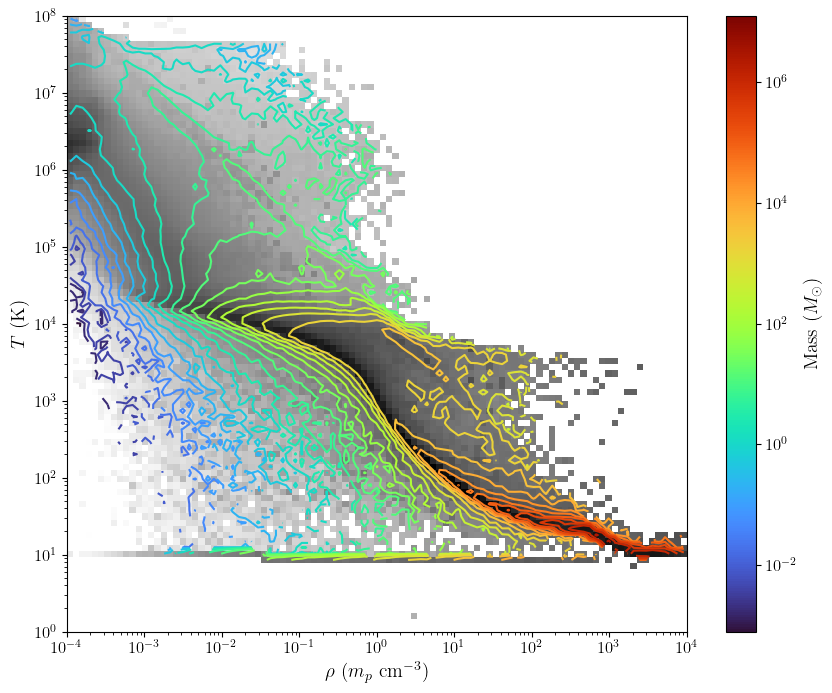

In [20]:
fig, ax = plt_phase( d, cmap="Greys", show_cbar=False, figsize=( 10, 8 ) )
plt_phase( d, fig=fig, ax=ax, plot_contour=True, contour_fill=False, levels=30, R_out = 500, Z_out = 140 )

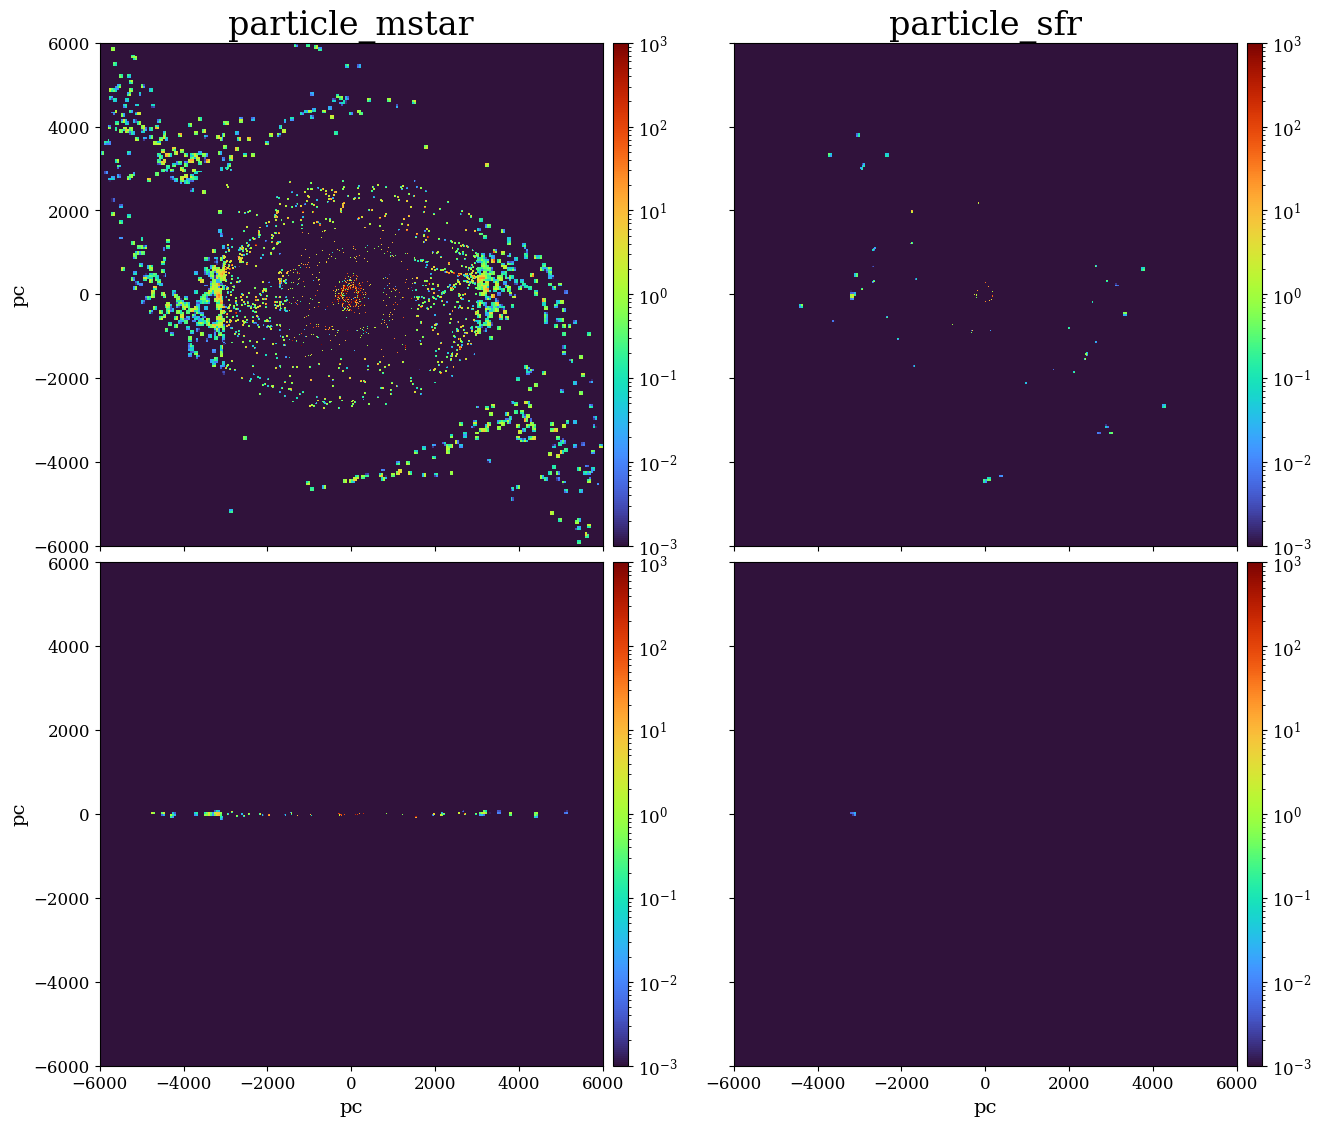

In [33]:
enroll_mesh_tree( d )
map_particle_blk( d, "particle_mstar", "particle_sfr" )
fig3 = f_plot_grid( d,  figsize=( 15, 13.5 ),
                    xlims = [ ( -6000, 6000 ), ( -6000, 6000 ) ], 
                    ylims = [ ( -6000, 6000 ), ( -6000, 6000 ) ],
                   flds = [ 'particle_mstar', "particle_sfr" ],
                   part_plot_i = [] )

/tmp/ipykernel_2809589/1609533543.py:21: RuntimeWarning: overflow encountered in multiply
  ax.hist(( mstar[ in_cmz ] )*m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
/tmp/ipykernel_2809589/1609533543.py:25: RuntimeWarning: overflow encountered in multiply
  ax.hist(( mstar[ in_cmz & recent ] )         *m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),


2206


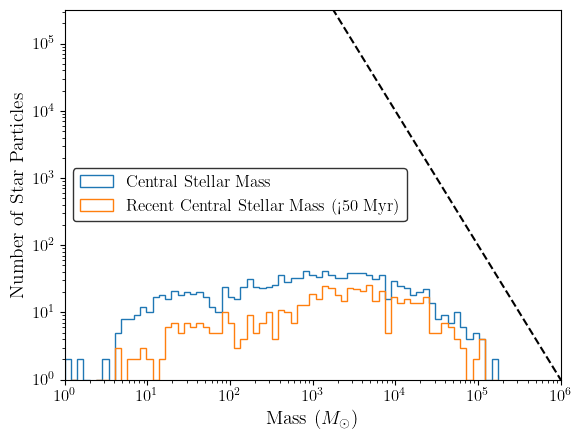

In [21]:
d_out = d
r = np.sqrt( np.sum( d_out.data['particle_x'].T**2, axis=0 ) )
R = np.sqrt( np.sum( d_out.data['particle_x'].T[ :2 ]**2, axis=0 ) )
z = d_out.data['particle_x'].T[ 2 ]
tcreate = d_out.data['particle_tcreate']
age     = d_out.data['particle_age']

in_cmz = ( R < 500 ) & ( np.abs( z ) < 140 )
recent = age < 50

mstar = d_out.data['particle_mstar']
m = d_out.data['particle_m']
sfr = d_out.data['particle_sfr']
SFdelay = d_out.data['particle_SFdelay']
RS0 = d_out.data['particle_RS0']
f,ax = plt.subplots()

xminlog = 0
xmaxlog = 6

ax.hist(( mstar[ in_cmz ] )*m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
         histtype='step',fill=False,stacked=False, label='Central Stellar Mass')
#ax.hist(( m    [ in_cmz ] )*m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
#         histtype='step',fill=False,stacked=False, label='Central Total Mass')
ax.hist(( mstar[ in_cmz & recent ] )         *m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
         histtype='step',fill=False,stacked=False, label='Recent Central Stellar Mass (<50 Myr)')
#ax.hist(( m )         *m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
#         histtype='step',fill=False,stacked=False, label='Recent Central Mass')
#ax.hist(( m - mstar )*m0/modot,bins=10**np.linspace(1,5,80),
#         histtype='step',fill=False,stacked=False, label='Gas Mass')
ax.set_xscale('log')
ax.set_yscale('log')
x = 10**np.linspace(2,10,100)
ax.plot(x, 10**12*x**-2, '--k')
ax.set_xlabel(r"Mass ($M_\odot$)")
plt.xlim([10**xminlog,10**xmaxlog])
ax.set_ylim([1e0,10**5.5])
ax.set_ylabel("Number of Star Particles")
ax.legend()
print( len( m ) )


Text(0, 0.5, 'Stellar Mass Formed ($M_\\odot$)')

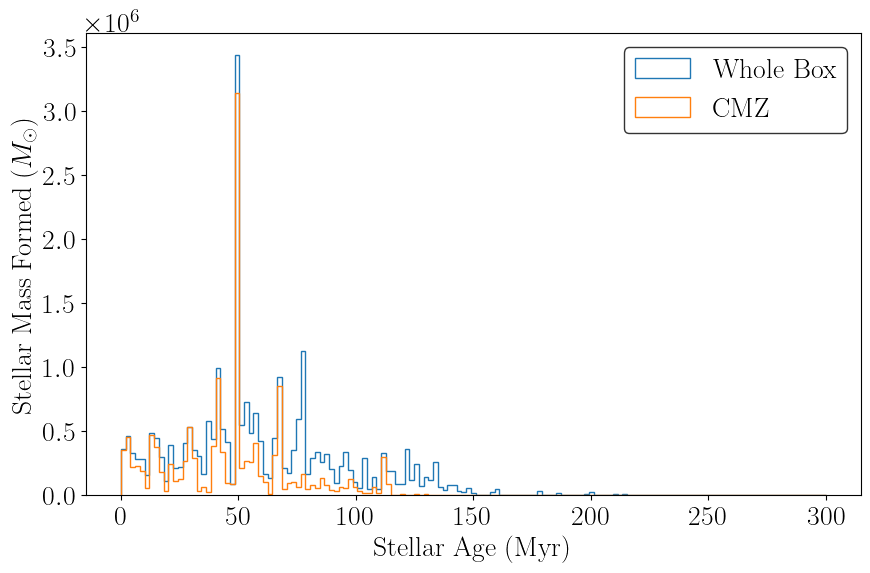

In [22]:
plt.rcParams['font.size'] = 20
f,ax = plt.subplots(1,1,figsize=( 10, 6 ) )
conv = m0 / modot
tcreate = d_out.data['particle_tcreate']
age     = d_out.data['particle_age']
bins = np.linspace( 0, 300, 150 )
ax.hist( age, weights=mstar*conv, bins=bins, histtype='step', fill=False, label='Whole Box' )
ax.hist( age[ in_cmz ], weights=mstar[ in_cmz ]*conv, bins=bins, histtype='step', fill=False, label='CMZ' )
ax.legend( fontsize=20 )
ax.set_xlabel( "Stellar Age (Myr)",fontsize=20 )
ax.set_ylabel( "Stellar Mass Formed ($M_\odot$)",fontsize=20 )

file: ../../cmz/cmz_test/outputs/cmz_fid4_b10_00065.bin; time = 325


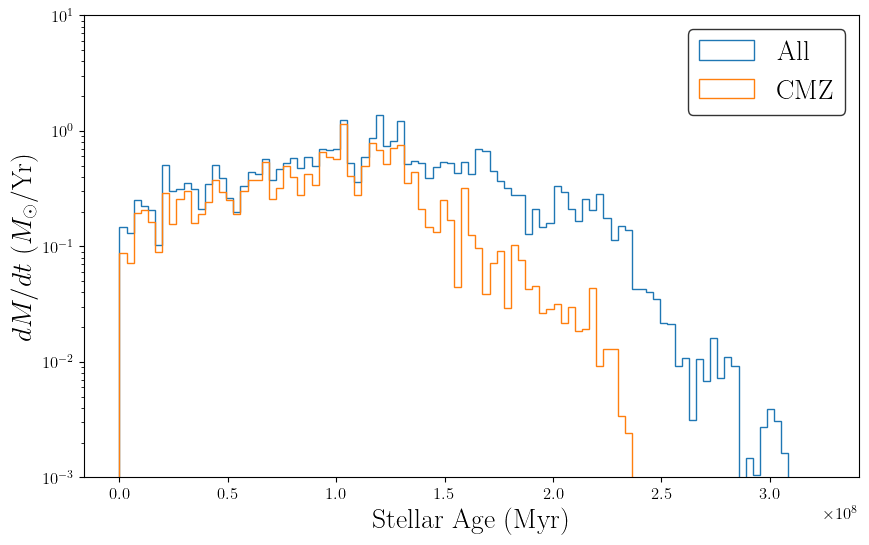

In [2]:
d  = get_last_dd( f'../../cmz/cmz_test/outputs/cmz_fid4_b10_{fstring( 65 )}.bin', -1, enroll_prim=True, data_type = galaxy_data );
d.load_particles( )
filter = par_pos_cut( d, 500, [ -140, 140 ], coord='cyl' )
all_ages = d.data['particle_age'] * 1e6
cmz_ages = d.data['particle_age'][ filter ] * 1e6
mstar    = d.data['particle_mstar']
bins = np.linspace( 0, d.globals['time']*1e6, 100 )
conv = m0 / modot / np.diff( bins )[ 0 ]
f,ax = plt.subplots(1,1,figsize=( 10, 6 ) )
ax.hist( all_ages, weights=mstar*conv, bins=bins, histtype='step', fill=False, label='All' )
ax.hist( cmz_ages, weights=mstar[ filter ]*conv, bins=bins, histtype='step', fill=False, label='CMZ' )
ax.set_yscale( 'log' )
ax.set_ylim( [1e-3, 1e1] )
ax.legend( fontsize=20 )
ax.set_xlabel( "Stellar Age (Myr)",fontsize=20 )
ax.set_ylabel( r"$dM/dt$ ($M_\odot$/Yr)",fontsize=20 )
plt.savefig( "../../cmz/paper_plots/SB_SFH.png", bbox_inches='tight' )

In [37]:
cmz_mstar = np.sum( ( mstar )[ in_cmz ] ) * m0 / modot / 1e8
cmz_sfr = np.sum(sfr[ in_cmz ]) * m0 / modot / ( t0 / yr )
cmz_sfrv2 = np.sum(sfr[ (SFdelay == 0) & in_cmz ]) * m0 / modot / ( t0 / yr )
print( cmz_mstar, cmz_sfr )

0.6139088605804363 0.22257566603145512


In [38]:
d_out.data.keys( )

dict_keys(['block_0', 'block_100', 'block_101', 'block_102', 'block_103', 'block_104', 'block_105', 'block_106', 'block_107', 'block_108', 'block_109', 'block_10', 'block_110', 'block_111', 'block_112', 'block_113', 'block_114', 'block_115', 'block_116', 'block_117', 'block_118', 'block_119', 'block_11', 'block_120', 'block_121', 'block_122', 'block_123', 'block_124', 'block_125', 'block_126', 'block_127', 'block_128', 'block_129', 'block_12', 'block_130', 'block_131', 'block_132', 'block_133', 'block_134', 'block_135', 'block_136', 'block_137', 'block_138', 'block_139', 'block_13', 'block_140', 'block_141', 'block_142', 'block_143', 'block_144', 'block_145', 'block_146', 'block_147', 'block_148', 'block_149', 'block_14', 'block_150', 'block_151', 'block_152', 'block_153', 'block_154', 'block_155', 'block_156', 'block_157', 'block_158', 'block_159', 'block_15', 'block_160', 'block_161', 'block_162', 'block_163', 'block_164', 'block_165', 'block_166', 'block_167', 'block_168', 'block_16

In [3]:
dyt = load_kratos_yt( d )#, fld_extra = [ "particle_mstar", "particle_sfr" ] )

yt : [WARNING  ] 2026-06-30 03:50:57,823 Overriding code units: Use this option only if you know that the dataset doesn't define the units correctly or at all.
yt : [INFO     ] 2026-06-30 03:50:57,824 Overriding length_unit: 3.0857e+18 cm.
yt : [INFO     ] 2026-06-30 03:50:57,825 Overriding time_unit: 31536000000000.0 s.
yt : [INFO     ] 2026-06-30 03:50:57,826 Overriding mass_unit: 4.914262907092623e+31 g.
yt : [WARNING  ] 2026-06-30 03:50:57,827 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-06-30 03:50:57,896 Parameters: current_time              = 325.00010909737057
yt : [INFO     ] 2026-06-30 03:50:57,896 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-06-30 03:50:57,897 Parameters: domain_left_edge          = [-6000. -6000. -6000.]
yt : [INFO     ] 2026-06-30 03:50:57,898 Parameters: domain_right_edge         = [6000. 6000. 6000.]
yt : [INFO     ] 2026-06-30 03:50:57,899 Parameters: cosmological_simulation   = 0


yt : [INFO     ] 2026-06-17 20:57:02,650 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:57:02,651 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:57:02,653 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:57:02,653 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:57:02,654 Making a fixed resolution buffer of (('gas', 'temperature')) 800 by 800



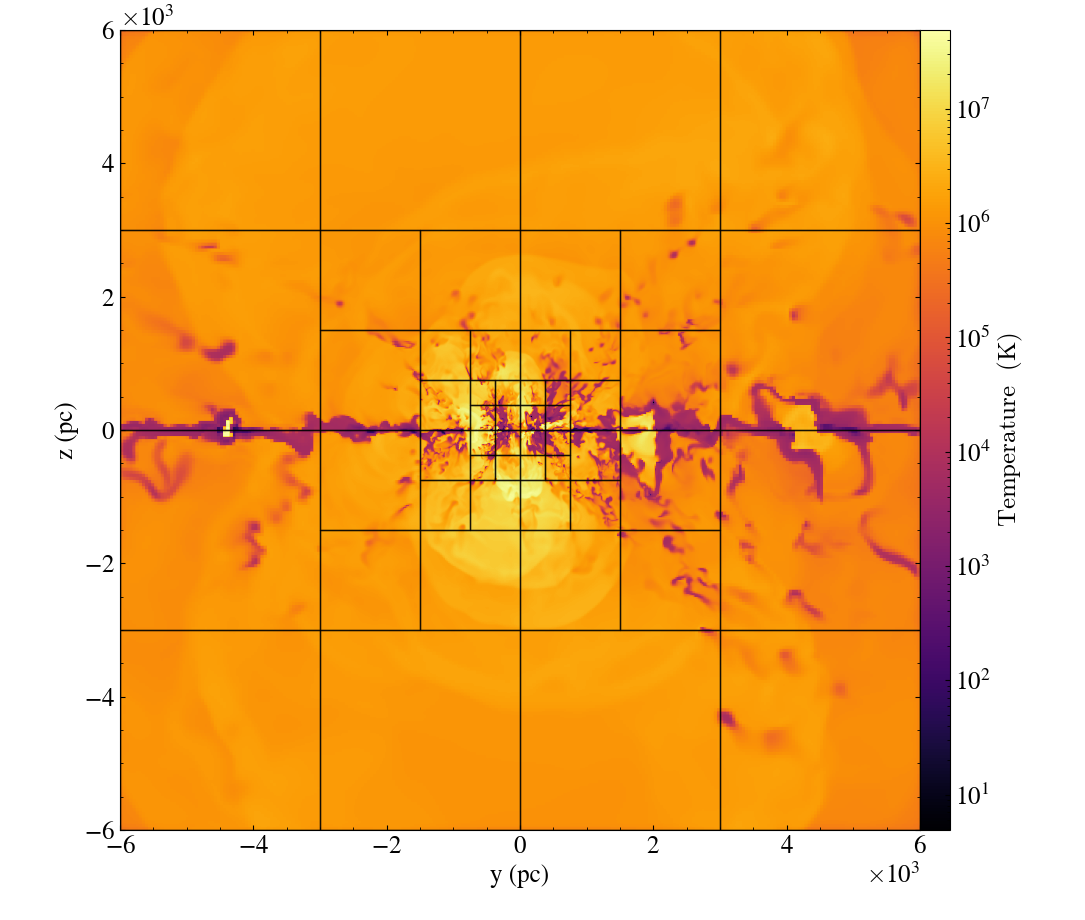

In [50]:
import yt


slc = yt.SlicePlot(dyt, "x", ("gas", "temperature"))
slc.set_cmap(("gas", "temperature"), "inferno")
slc.set_unit(("gas", "temperature"), "K")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)

#slc.save("yt_temp.png")
slc.show()

yt : [INFO     ] 2026-06-17 20:57:45,209 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:57:45,210 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:57:45,212 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:57:45,213 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:57:45,214 Making a fixed resolution buffer of (('athena_pp', 'temperature')) 800 by 800



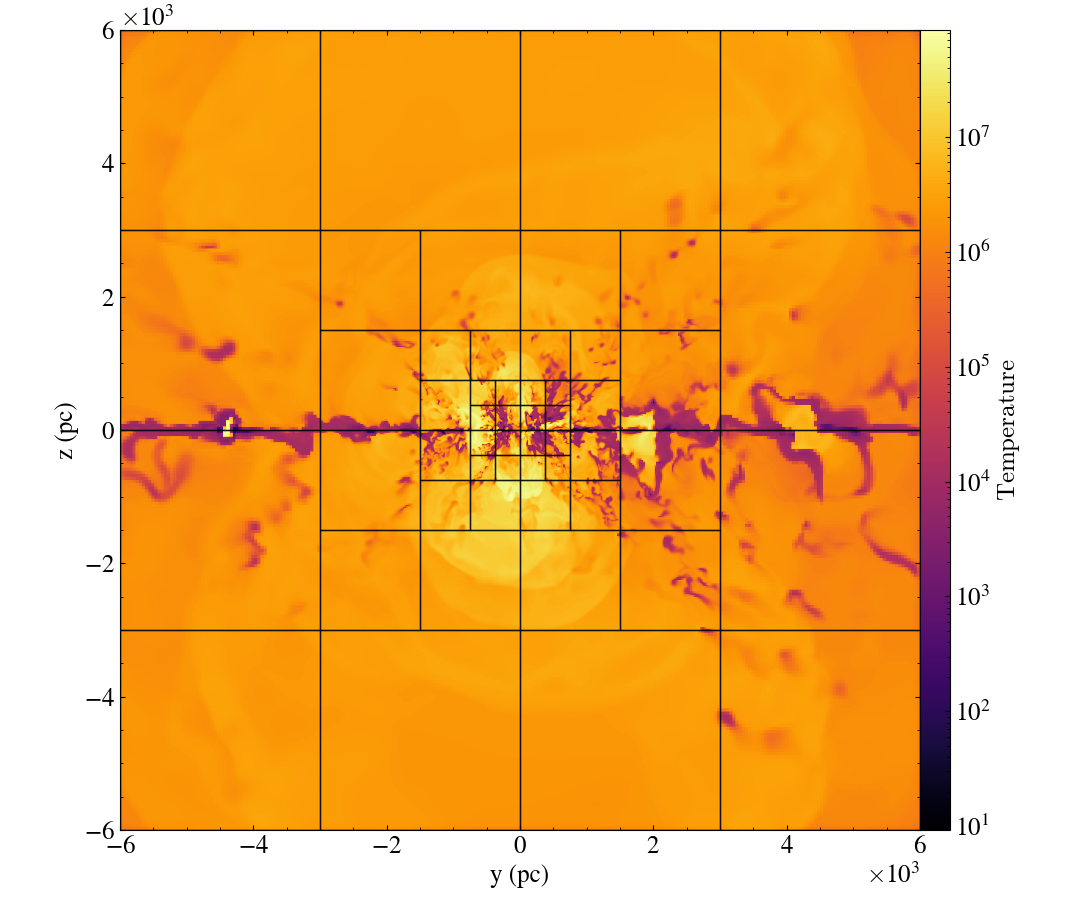

In [52]:
slc = yt.SlicePlot(dyt, "x", ("athena_pp", "temperature"))
slc.set_cmap(("athena_pp", "temperature"), "inferno")
#slc.set_unit(("athena_pp", "temperature"), "K")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)

#slc.save("yt_temp.png")
slc.show()

yt : [INFO     ] 2026-06-17 20:48:07,048 Projection completed
yt : [INFO     ] 2026-06-17 20:48:07,050 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:07,051 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:07,053 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:07,054 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:07,055 Making a fixed resolution buffer of (('gas', 'temperature')) 800 by 800



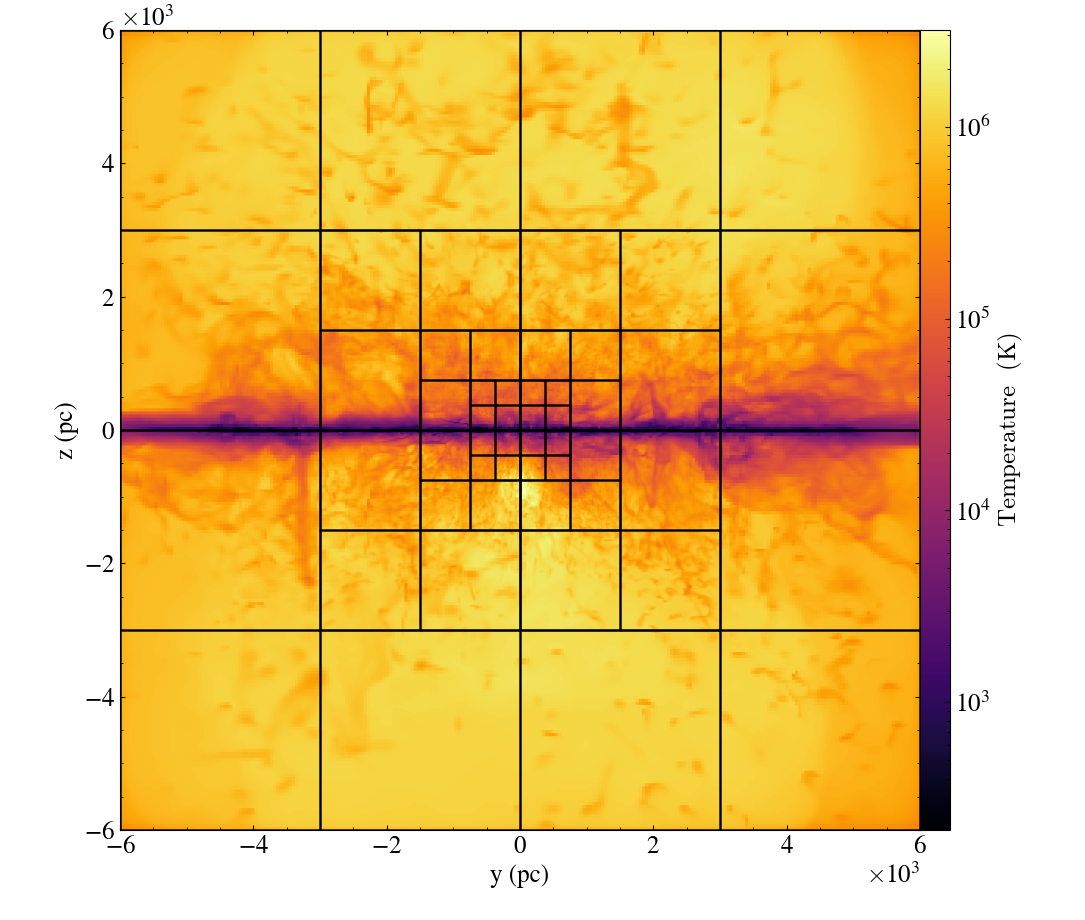

In [41]:
slc = yt.ProjectionPlot(dyt, "x", ("gas", "temperature"),weight_field=("gas","density"))
slc.set_cmap(("gas", "temperature"), "inferno")
slc.set_unit(("gas", "temperature"), "K")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)

#slc.save("yt_temp.png")
slc.show()

yt : [INFO     ] 2026-06-17 20:48:07,810 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:07,811 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:07,813 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:07,813 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:07,814 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



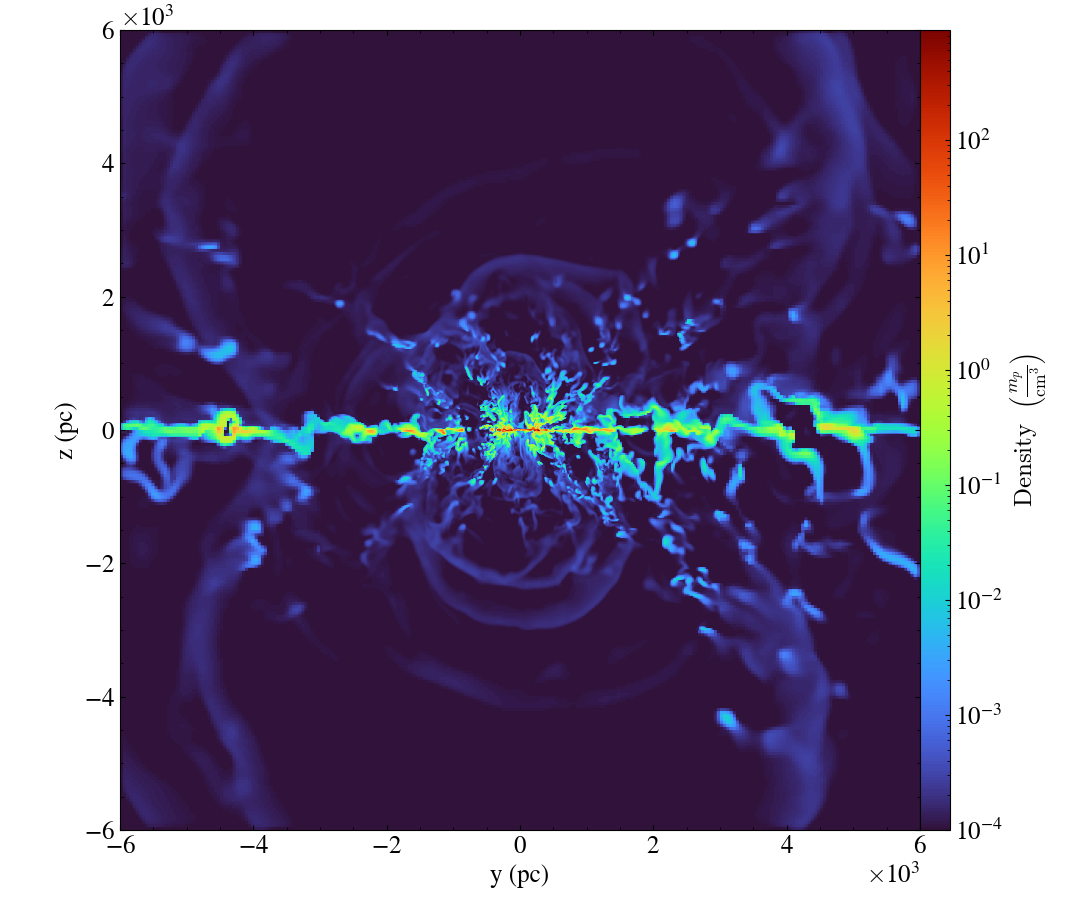

In [42]:
slc = yt.SlicePlot(dyt, "x", ("gas", "density"))
slc.set_cmap(("gas", "density"), "turbo")
slc.set_unit(("gas", "density"), "mp/cm**3")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
#slc.annotate_grids(cmap=None)
#slc.annotate_streamlines(("gas", "velocity_y"), ("gas", "velocity_z"), density=2, color='white')
#slc.save("slice_dens_streamlines.png")#,bbox_inches='tight', dpi=300)
slc.show()

yt : [INFO     ] 2026-06-17 20:48:08,578 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:08,578 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:08,580 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:08,581 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:08,582 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



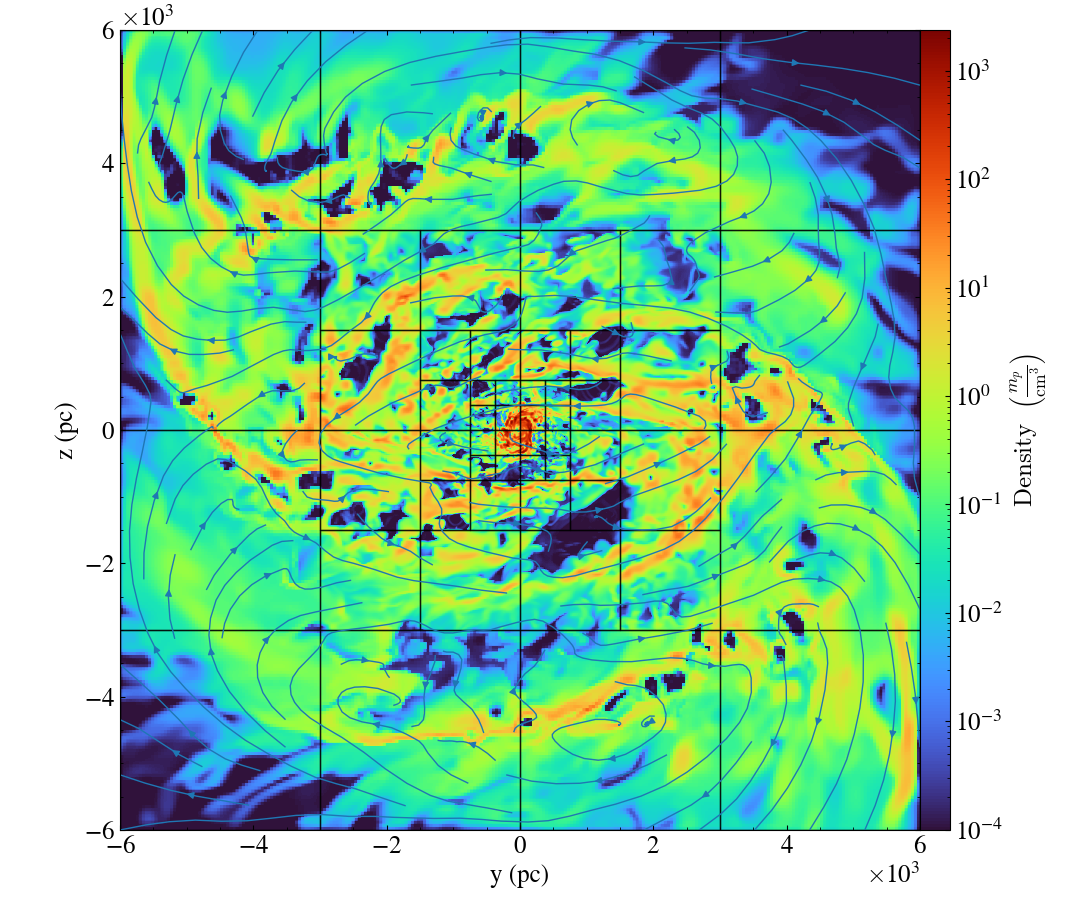

In [43]:
slc = yt.SlicePlot(dyt, "z", ("gas", "density"))
slc.set_cmap(("gas", "density"), "turbo")
slc.set_unit(("gas", "density"), "mp/cm**3")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)
slc.annotate_streamlines(("gas", "velocity_x"), ("gas", "velocity_y"))
#slc.save("slice_dens_faceon.png")
slc.show()

yt : [INFO     ] 2026-06-17 20:48:14,711 Projection completed
yt : [INFO     ] 2026-06-17 20:48:14,712 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:14,713 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:14,715 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:14,715 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:14,716 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800
yt : [INFO     ] 2026-06-17 20:48:15,107 Saving plot yt_dens_faceon.png



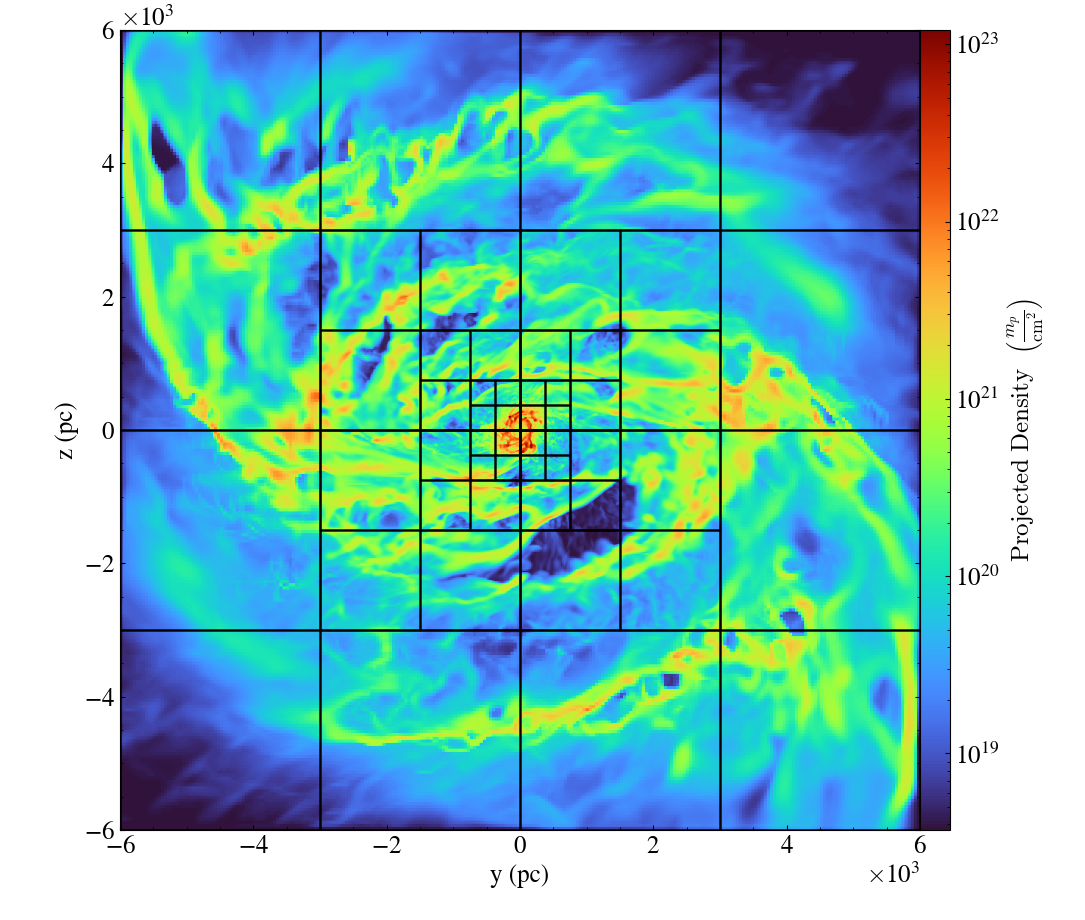

In [ ]:
slc = yt.ProjectionPlot(dyt, "z", ("gas", "density"))
slc.set_cmap(("gas", "density"), "turbo")
slc.set_unit(("gas", "density"), "mp/cm**2")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('x (pc)')
slc.set_ylabel('y (pc)')
slc.annotate_grids(cmap=None)
slc.save("yt_dens_faceon.png")
slc.show()

In [ ]:
d  = get_last_dd( f'../../cmz/cmz_test/outputs/cmz_fid4_b10_{fstring( 50 )}.bin', -1, enroll_prim=True, data_type = galaxy_data );
dyt = load_kratos_yt( d )
def _temp_K(field, data):
    return data[("athena_pp", "temperature")].in_units("K")

# But if it's dimensionless, force the unit:
def _temp_K(field, data):
    arr = data[("athena_pp", "temperature")]
    return dyt.arr(arr.v, "K")   # attach units manually

dyt.add_field(
    ("gas", "temperature_K"),
    function=_temp_K,
    units="K",
    sampling_type="cell",
    force_override=True )

slc = yt.ProjectionPlot(dyt, "z", ("gas", "temperature_K"),
                         weight_field=("gas", "density"), buff_size=(2048, 2048) )
slc.set_unit(("gas", "temperature_K"), "K")   # now works
slc.set_axes_unit( 'pc' )
slc.set_cmap(("gas", "temperature_K"), "inferno")
slc.set_xlabel('x (pc)')
slc.set_ylabel('y (pc)')
slc.set_zlim( ("gas","temperature_K"), zmin=(1e1, "K"), zmax=(1e7, "K") )
#slc.annotate_grids(cmap=None)
slc.save("SB_temp_faceon.png")
slc.show()

yt : [INFO     ] 2026-06-17 20:48:20,458 Projection completed
yt : [INFO     ] 2026-06-17 20:48:20,461 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:20,461 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:20,464 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:20,465 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:20,466 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



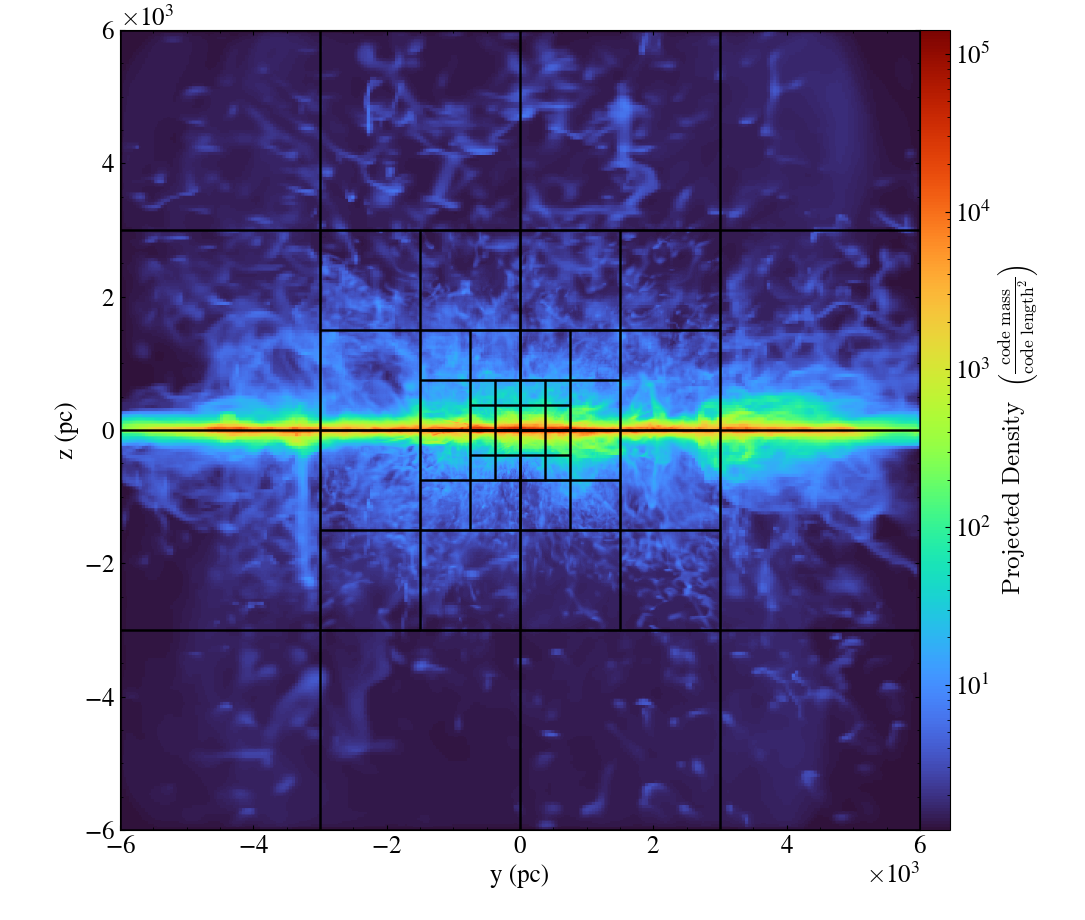

In [45]:
slc = yt.ProjectionPlot(dyt, "x", ("gas", "density"))
slc.set_cmap(("gas", "density"), "turbo")
#slc.set_unit(("gas", "density"), "mp/cm**3")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)
#slc.save("yt_dens.png")
slc.show()

yt : [INFO     ] 2026-06-17 20:48:21,686 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:21,687 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:21,689 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:21,689 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 20:48:21,690 Making a fixed resolution buffer of (('athena_pp', 'metallicity')) 800 by 800



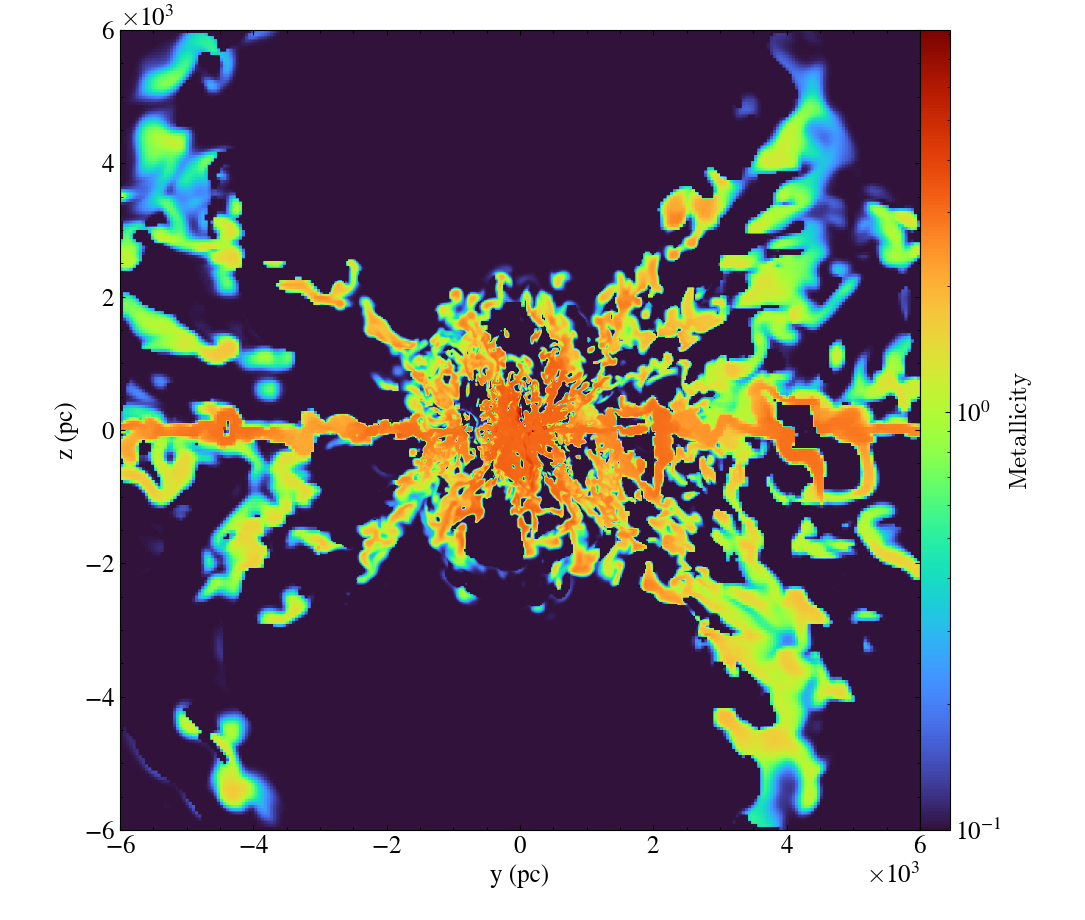

In [46]:
slc = yt.SlicePlot(dyt, "x", ("athena_pp", "metallicity") )
slc.set_cmap(("athena_pp", "metallicity"), "turbo")
#slc.set_unit(("gas", "density"), "mp/cm**3")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
#slc.annotate_grids(cmap=None)
#slc.annotate_streamlines(("gas", "velocity_y"), ("gas", "velocity_z"), density=2, color='white')
#slc.save("slice_dens_streamlines.png")#,bbox_inches='tight', dpi=300)
slc.show()

In [57]:
def _temperature(field, data):
    return data["athena_pp", "temperature"]  # your existing calculation

dyt.add_field(
    ("athena_pp", "temperature"),
    function=_temperature,
    sampling_type="cell",
    force_overrite=True,
    units="K"  # Add your desired unit here
)

yt : [WARNING  ] 2026-06-17 21:04:11,898 Field ('athena_pp', 'temperature') already exists. To override use `force_override=True`.


In [65]:
dyt.field_info["athena_pp", "temperature"].units = "K"
dyt.field_info["athena_pp", "temperature"].output_units = "K"
dyt.all_data()["athena_pp", "temperature"]

unyt_array([ 477482.17073458,  430114.422445  ,  494959.13542213, ...,
       7284012.05813939, 8160625.37789585, 9000787.06255558], 'K')

In [5]:
from matplotlib.ticker import FuncFormatter
import pyxsim
from math import floor
D = 8000
def y_to_angle( y, pos ):
    theta = np.arctan(y / D)
    return f"{np.degrees(theta):.2f}°"
def x_to_RA( x, pos ):
    theta = np.arctan(-x / D)
    if theta < 0:
        theta += 2*np.pi#- theta
    RA = theta * 12 / np.pi
    hour = int( floor( RA ) )
    min = round( ( RA - hour ) * 60 )
    return f"{hour} h {min}"
thermal_model  = pyxsim.CIESourceModel( "cloudy", 0.2, 11, 10000, ( "athena_pp", "metallicity" ), 
                                       kT_min=0.2, emission_measure_field=( "gas", "density" ),
                                        temperature_field=( "gas", "temperature_K" )  )
#thermal_model  = pyxsim.CIESourceModel( "cloudy", 0.2, 11, 10000, 1, kT_min=0.2, emission_measure_field=( "gas", "density" )  )
#thermal_model2 = pyxsim.IGMSourceModel( "cloudy", 0.05, 11, 10000, ( "athena_pp", "metallicity" ), kT_min=0.1, emission_measure_field=( "gas", "density" )  )
xray = thermal_model.make_source_fields( dyt, 0.6, 1 )
prj = yt.ProjectionPlot(
    dyt, "x", ("gas", 'xray_photon_count_rate_0.6_1_keV') )#, weight_field=( "gas", "mass" ) )
#)
#prj.set_unit( ("gas", 'xray_emissivity_0.6_1_keV'), "erg/s/cm**2" )
prj.set_axes_unit( 'pc' )
prj.set_ylabel('Galactic Latitude')
prj.set_xlabel('Right Ascension')

prj._setup_plots()
ax = prj.plots[("gas", 'xray_photon_count_rate_0.6_1_keV')].axes
ax.yaxis.set_major_formatter(FuncFormatter(y_to_angle))
ax.xaxis.set_major_formatter(FuncFormatter(x_to_RA))
prj.show()

pyxsim : [WARNING  ] 2026-06-30 03:53:08,280 For the 'cloudy' model, the only available abundance table is 'feld', so using that one.
pyxsim : [INFO     ] 2026-06-30 03:53:08,462 kT_min = 0.2 keV
pyxsim : [INFO     ] 2026-06-30 03:53:08,463 kT_max = 64 keV


YTFieldNotFound: Could not find field ('gas', 'temperature_K') in tmpogx7lsam.
Did you mean:
	('gas', 'temperature')

yt : [INFO     ] 2026-06-17 21:14:33,620 Projection completed
yt : [INFO     ] 2026-06-17 21:14:33,623 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 21:14:33,624 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 21:14:33,627 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 21:14:33,627 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-17 21:14:33,628 Making a fixed resolution buffer of (('gas', 'xray_emissivity_0.6_1_keV')) 800 by 800


Simulation extent: x=[-6000, 6000] pc, y=[-6000, 6000] pc
Max angle: RA=36.9°, Dec=36.9°
RA range:  [0.1°, 359.9°]
Dec range: [-36.9°, 36.9°]


/home/cmz_colab/.local/lib/python3.10/site-packages/skyproj/_skyproj.py:636: FutureWarning: skyproj.pcolormesh() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.pcolormesh()
  warnings.warn(


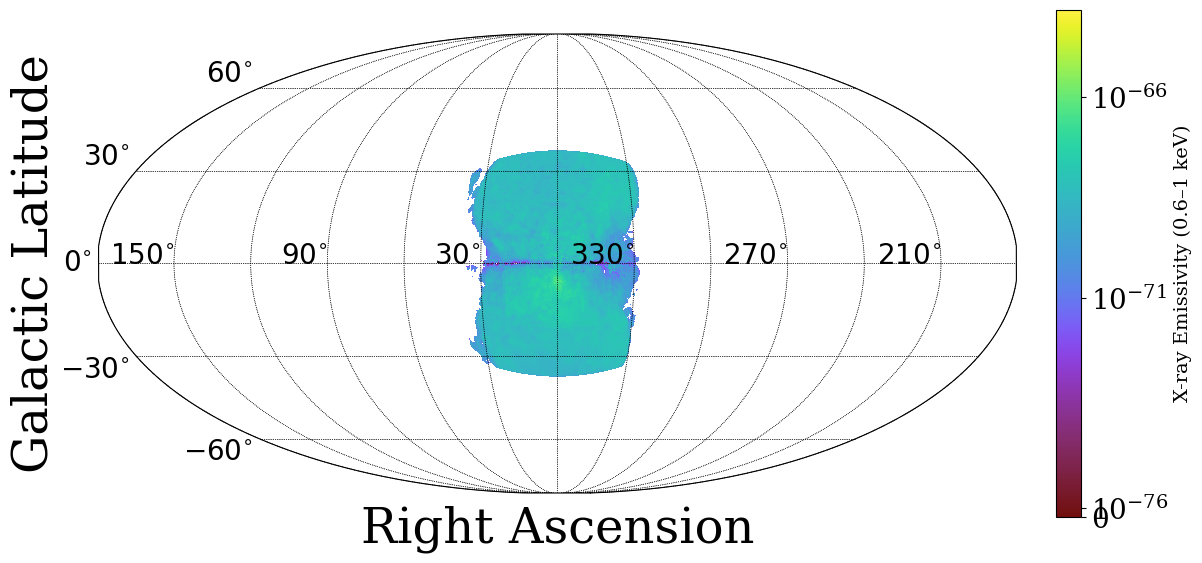

In [67]:
import skyproj

D = 8000  # pc — observer distance

# --- 1. Extract yt image ---
prj = yt.ProjectionPlot(
    dyt, "x", ("gas", "xray_emissivity_0.6_1_keV"), weight_field=("gas", "mass")
)
prj.set_axes_unit("pc")
prj._setup_plots()

yt_plot = prj.plots[("gas", "xray_emissivity_0.6_1_keV")]
yt_ax   = yt_plot.axes
img     = yt_ax.get_images()[0]
data    = img.get_array().copy()
extent  = img.get_extent()          # [xmin_pc, xmax_pc, ymin_pc, ymax_pc]
xmin_pc, xmax_pc, ymin_pc, ymax_pc = extent

print(f"Simulation extent: x=[{xmin_pc:.0f}, {xmax_pc:.0f}] pc, "
      f"y=[{ymin_pc:.0f}, {ymax_pc:.0f}] pc")
print(f"Max angle: RA={np.degrees(np.arctan(abs(xmax_pc)/D)):.1f}°, "
      f"Dec={np.degrees(np.arctan(abs(ymax_pc)/D)):.1f}°")

# --- 2. Build pixel-center coordinate grids ---
ny, nx = data.shape
# pixel centers (not edges)
xs_pc = np.linspace(xmin_pc, xmax_pc, nx)
ys_pc = np.linspace(ymin_pc, ymax_pc, ny)
XX, YY = np.meshgrid(xs_pc, ys_pc)

# Angular distance from observer at (D, 0, 0) looking toward Galactic center
# RA: arctan of transverse x offset (note sign convention: RA increases left)
RA_deg  = np.degrees(np.arctan2(-XX, D)) % 360   # 0–360°
Dec_deg = np.degrees(np.arctan2( YY, np.sqrt(XX**2 + D**2)))  # true elevation

# --- 3. Sanity-check the angular range ---
print(f"RA range:  [{RA_deg.min():.1f}°, {RA_deg.max():.1f}°]")
print(f"Dec range: [{Dec_deg.min():.1f}°, {Dec_deg.max():.1f}°]")

# --- 4. Mask zeros/negatives ---
masked_data = np.ma.masked_where(data <= 0, data)

cmap = img.cmap
cmap.set_bad(color='none')
norm = img.norm

# --- 5. pcolormesh needs CORNER coordinates, not centers ---
# Compute edge grids (shape ny+1, nx+1) for pcolormesh
xs_edge = np.linspace(xmin_pc, xmax_pc, nx + 1)
ys_edge = np.linspace(ymin_pc, ymax_pc, ny + 1)
XXe, YYe = np.meshgrid(xs_edge, ys_edge)
RA_edge  = np.degrees(np.arctan2(-XXe, D)) % 360
Dec_edge = np.degrees(np.arctan2( YYe, np.sqrt(XXe**2 + D**2)))

# --- 6. Plot ---
fig, raw_ax = plt.subplots(figsize=(12, 6))
sp = skyproj.MollweideSkyproj(
    ax=raw_ax,
    lon_0=0,          # center on RA=0 (Galactic center)
    celestial=True,
    gridlines=True,
)

# pcolormesh with explicit 2D corner arrays — no smearing
pcm = sp.pcolormesh(
    RA_edge, Dec_edge, masked_data,
    norm=norm,
    cmap=cmap,
    rasterized=True,
)

sp.ax.set_xlabel("Right Ascension")
sp.ax.set_ylabel("Galactic Latitude")
fig.colorbar(pcm, ax=sp.ax, label="X-ray Emissivity (0.6–1 keV)",
             fraction=0.03, pad=0.04)
plt.tight_layout()
plt.show()